# 02 — Stock Predictor Engine
**NIFTY-50 Investment Intelligence Platform**

Loads processed data from Notebook 1 → builds ML models → evaluates → generates BUY/HOLD/SELL signals → saves to Drive for Notebook 3.

In [2]:
# ── CELL 1: Load processed data from Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('/content/drive/MyDrive/nifty50_processed_data.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(['Symbol', 'Date'], inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"Loaded ✅  Shape: {data.shape}")
print(f"Columns : {data.columns.tolist()}")
print(f"Symbols : {data['Symbol'].nunique()}")
print(f"Date range: {data['Date'].min().date()} → {data['Date'].max().date()}")

Mounted at /content/drive
Loaded ✅  Shape: (235192, 33)
Columns : ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'Sector', 'Daily_Return', 'MA20', 'MA50', 'MA200', 'EMA20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Volatility_21', 'Momentum_20', 'Price_Position', 'Volume_Change']
Symbols : 49
Date range: 2000-01-03 → 2021-04-30


In [3]:
# ── CELL 2: Prepare Features & Target ────────────────────────────────────────
FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'MA20', 'MA50', 'MA200', 'EMA20',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Width',
    'Volatility_21', 'Momentum_20',
    'Price_Position', 'Volume_Change', 'Daily_Return'
]

# Target: next day's closing price
data['Target'] = data.groupby('Symbol')['Close'].shift(-1)

# Drop rows with NaN in features or target
model_data = data[FEATURES + ['Target', 'Symbol', 'Date']].dropna()

print(f"Model data shape : {model_data.shape}")
print(f"Features used    : {len(FEATURES)}")
print(f"\nFeature list:\n{FEATURES}")

Model data shape : (225326, 24)
Features used    : 21

Feature list:
['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'MA200', 'EMA20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Volatility_21', 'Momentum_20', 'Price_Position', 'Volume_Change', 'Daily_Return']


In [4]:
# ── CELL 3: Train/Test Split (Time-Based) — RELIANCE ─────────────────────────
stock = 'RELIANCE'
df_stock = model_data[model_data['Symbol'] == stock].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

# 80% train, 20% test — strictly time-based (no data leakage)
split_idx = int(len(df_stock) * 0.80)

train = df_stock.iloc[:split_idx]
test  = df_stock.iloc[split_idx:]

X_train = train[FEATURES]
y_train = train['Target']
X_test  = test[FEATURES]
y_test  = test['Target']

print(f"Stock       : {stock}")
print(f"Total rows  : {len(df_stock)}")
print(f"Train size  : {len(train)} rows  ({train['Date'].min().date()} to {train['Date'].max().date()})")
print(f"Test size   : {len(test)}  rows  ({test['Date'].min().date()} to {test['Date'].max().date()})")

Stock       : RELIANCE
Total rows  : 5106
Train size  : 4084 rows  (2000-10-19 to 2017-03-10)
Test size   : 1022  rows  (2017-03-14 to 2021-04-29)


In [5]:
# ── CELL 4: Scale Features ────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✅")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")

Features scaled ✅
X_train_scaled shape : (4084, 21)
X_test_scaled  shape : (1022, 21)


In [6]:
# ── CELL 5: Model 1 — Random Forest ──────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# Metrics
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

# Directional Accuracy
actual_dir = np.sign(y_test.values - test['Close'].values)
rf_dir     = np.sign(rf_preds - test['Close'].values)
rf_da      = np.mean(actual_dir == rf_dir) * 100

print("=" * 40)
print("Random Forest Results")
print("=" * 40)
print(f"MAE                : {rf_mae:.2f}")
print(f"RMSE               : {rf_rmse:.2f}")
print(f"R² Score           : {rf_r2:.4f}")
print(f"Directional Acc    : {rf_da:.2f}%")

Random Forest Results
MAE                : 24.54
RMSE               : 41.65
R² Score           : 0.9886
Directional Acc    : 49.61%


In [7]:
# ── CELL 6: Model 2 — XGBoost ────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

# Metrics
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2   = r2_score(y_test, xgb_preds)

# Directional Accuracy
xgb_dir = np.sign(xgb_preds - test['Close'].values)
xgb_da  = np.mean(actual_dir == xgb_dir) * 100

print("=" * 40)
print("XGBoost Results")
print("=" * 40)
print(f"MAE                : {xgb_mae:.2f}")
print(f"RMSE               : {xgb_rmse:.2f}")
print(f"R² Score           : {xgb_r2:.4f}")
print(f"Directional Acc    : {xgb_da:.2f}%")

XGBoost Results
MAE                : 28.71
RMSE               : 48.05
R² Score           : 0.9849
Directional Acc    : 49.41%


                  Metric  Random Forest   XGBoost
                     MAE      24.535762 28.714503
                    RMSE      41.654727 48.046747
                R² Score       0.988634  0.984878
Directional Accuracy (%)      49.608611 49.412916


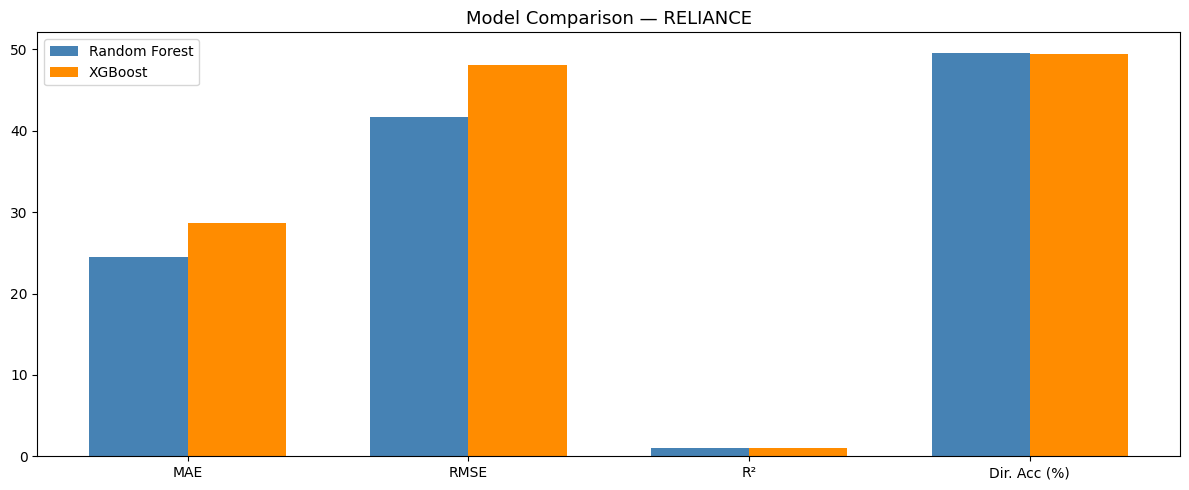

In [8]:
# ── CELL 7: Compare Both Models ───────────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score', 'Directional Accuracy (%)'],
    'Random Forest': [rf_mae, rf_rmse, rf_r2, rf_da],
    'XGBoost':       [xgb_mae, xgb_rmse, xgb_r2, xgb_da]
})

print(comparison.to_string(index=False))

# Bar chart comparison
metrics  = ['MAE', 'RMSE', 'R²', 'Dir. Acc (%)']
rf_vals  = [rf_mae, rf_rmse, rf_r2, rf_da]
xgb_vals = [xgb_mae, xgb_rmse, xgb_r2, xgb_da]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='steelblue')
ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title(f'Model Comparison — {stock}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

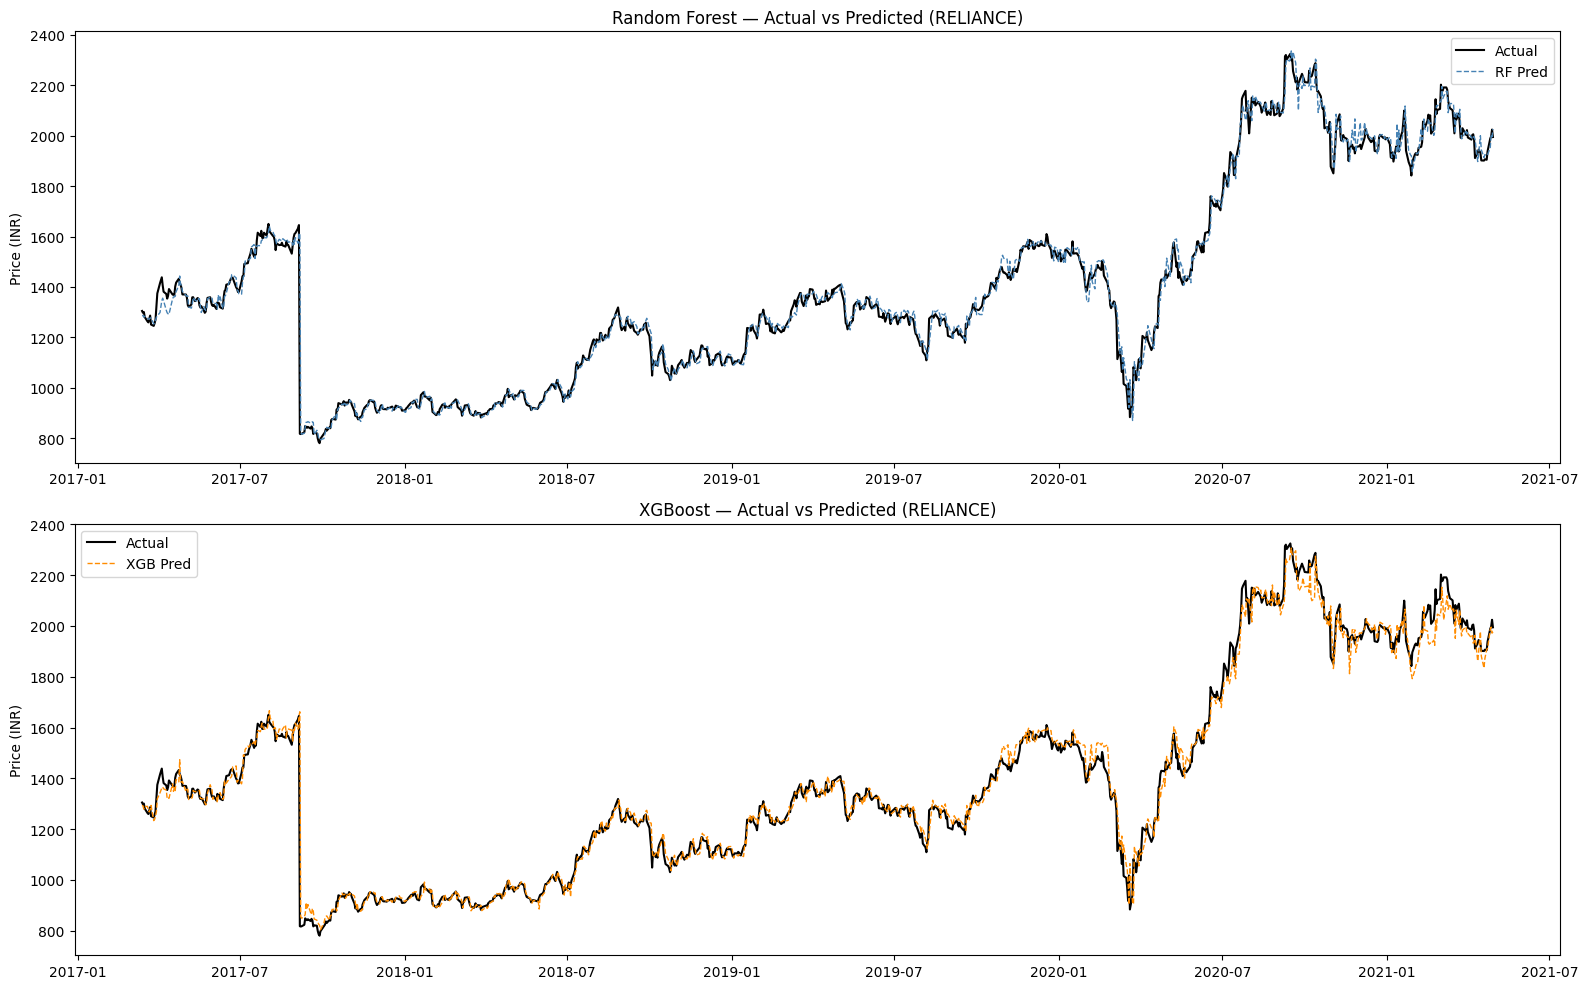

In [9]:
# ── CELL 8: Actual vs Predicted Chart ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Random Forest
axes[0].plot(test['Date'].values, y_test.values, label='Actual',  linewidth=1.5, color='black')
axes[0].plot(test['Date'].values, rf_preds,      label='RF Pred', linewidth=1,   linestyle='--', color='steelblue')
axes[0].set_title(f'Random Forest — Actual vs Predicted ({stock})', fontsize=12)
axes[0].legend()
axes[0].set_ylabel('Price (INR)')

# XGBoost
axes[1].plot(test['Date'].values, y_test.values, label='Actual',   linewidth=1.5, color='black')
axes[1].plot(test['Date'].values, xgb_preds,     label='XGB Pred', linewidth=1,   linestyle='--', color='darkorange')
axes[1].set_title(f'XGBoost — Actual vs Predicted ({stock})', fontsize=12)
axes[1].legend()
axes[1].set_ylabel('Price (INR)')

plt.tight_layout()
plt.show()

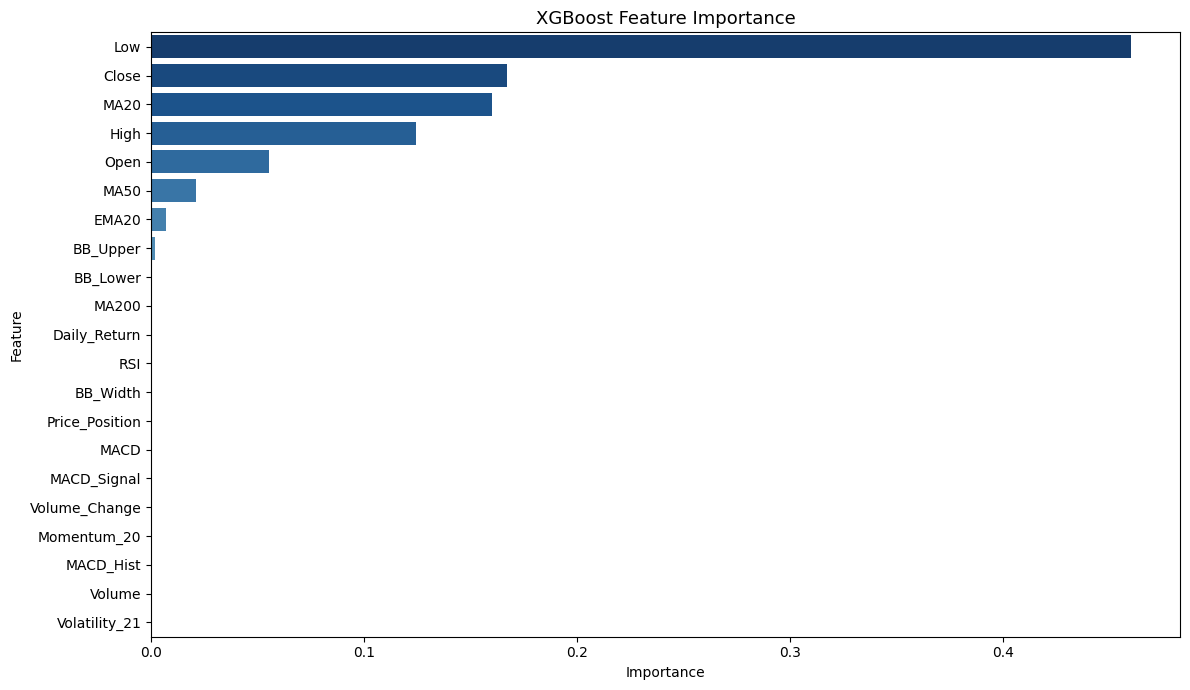

       Feature  Importance
           Low    0.459935
         Close    0.166988
          MA20    0.160190
          High    0.124288
          Open    0.055264
          MA50    0.021318
         EMA20    0.007032
      BB_Upper    0.001927
      BB_Lower    0.000599
         MA200    0.000467
  Daily_Return    0.000305
           RSI    0.000246
      BB_Width    0.000189
Price_Position    0.000185
          MACD    0.000181
   MACD_Signal    0.000169
 Volume_Change    0.000157
   Momentum_20    0.000154
     MACD_Hist    0.000148
        Volume    0.000132
 Volatility_21    0.000125


In [10]:
# ── CELL 9: Feature Importance (XGBoost) ─────────────────────────────────────
feat_imp = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
plt.title('XGBoost Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

In [13]:
# ── CELL 10: Test on ALL Stocks ───────────────────────────────────────────────
import os

results = []

for symbol in data['Symbol'].unique():
    df_s = model_data[model_data['Symbol'] == symbol].sort_values('Date').reset_index(drop=True)

    if len(df_s) < 200:   # skip stocks with too little data
        continue

    split  = int(len(df_s) * 0.8)
    tr, te = df_s.iloc[:split], df_s.iloc[split:]

    Xtr = scaler.fit_transform(tr[FEATURES])
    Xte = scaler.transform(te[FEATURES])

    m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42, verbosity=0)
    m.fit(Xtr, tr['Target'])
    preds = m.predict(Xte)

    rmse = np.sqrt(mean_squared_error(te['Target'], preds))
    r2   = r2_score(te['Target'], preds)
    da   = np.mean(np.sign(preds - te['Close'].values) == np.sign(te['Target'].values - te['Close'].values)) * 100

    results.append({
        'Symbol':          symbol,
        'RMSE':            round(rmse, 2),
        'R2':              round(r2, 4),
        'Directional_Acc': round(da, 2)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df.to_string(index=False))

# Ensure the directory exists before saving
os.makedirs('/content/data', exist_ok=True)

# Save locally
results_df.to_csv('/content/data/model_results.csv', index=False)
print("\nResults saved locally ✅")

    Symbol    RMSE      R2  Directional_Acc
TATAMOTORS    7.75  0.9959            50.00
      VEDL    5.24  0.9948            50.54
      GAIL   10.38  0.9944            48.69
        MM   29.62  0.9902            48.92
     TITAN   28.54  0.9894            49.90
  HDFCBANK   45.61  0.9890            51.57
 ICICIBANK   10.66  0.9873            50.78
 TATASTEEL   16.12  0.9860            50.59
ADANIPORTS   13.52  0.9850            51.52
      ZEEL   18.49  0.9850            47.85
        LT   25.22  0.9841            51.19
    GRASIM   28.02  0.9839            48.83
     CIPLA   15.03  0.9817            48.14
  RELIANCE   52.84  0.9817            50.98
      BPCL   13.57  0.9810            50.93
     TECHM   17.54  0.9803            47.16
  AXISBANK   16.46  0.9792            50.05
      SBIN    7.64  0.9779            51.86
  JSWSTEEL   12.70  0.9771            52.31
BAJFINANCE  176.03  0.9764            52.45
 SUNPHARMA   12.01  0.9764            49.90
ASIANPAINT   70.67  0.9730      

Model Performance Summary (All Stocks — XGBoost)
Stocks evaluated     : 49
Avg R² Score         : 0.5896
Avg RMSE             : 363.35
Avg Directional Acc  : 50.18%
Stocks with R² > 0.9 : 31
Stocks with Dir > 55%: 0


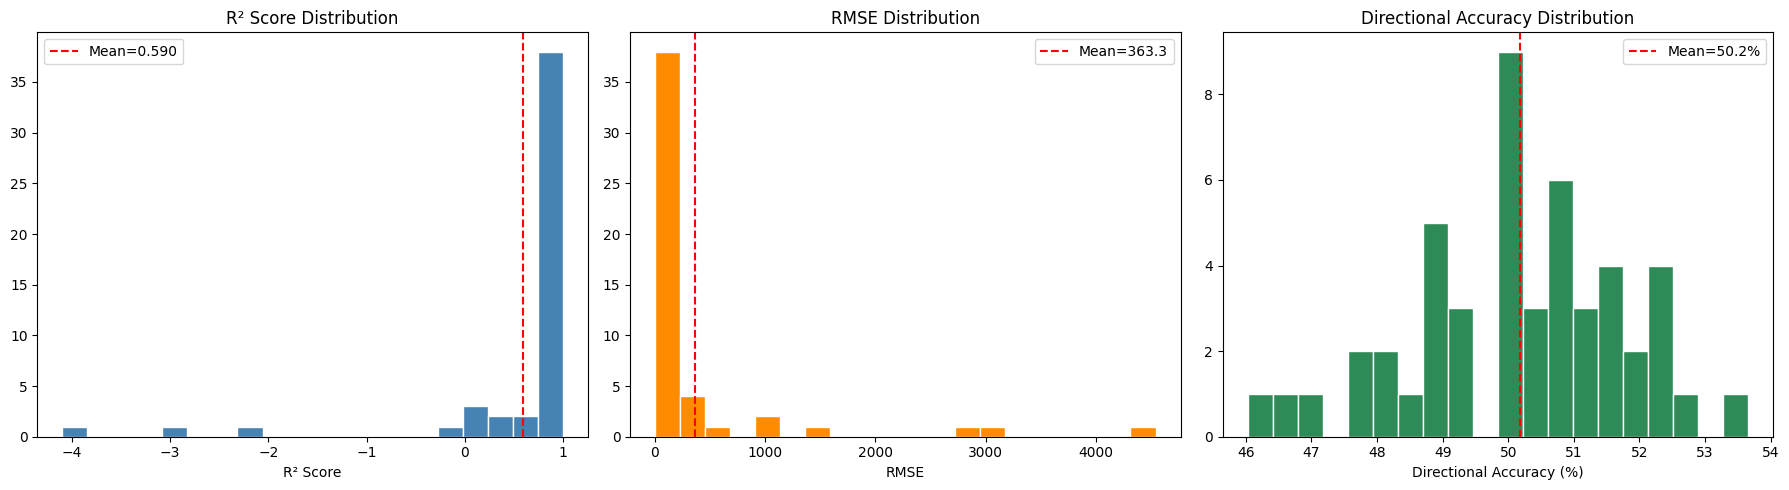

In [14]:
# ── CELL 11: Summary Stats of Model Performance ───────────────────────────────
print("=" * 50)
print("Model Performance Summary (All Stocks — XGBoost)")
print("=" * 50)
print(f"Stocks evaluated     : {len(results_df)}")
print(f"Avg R² Score         : {results_df['R2'].mean():.4f}")
print(f"Avg RMSE             : {results_df['RMSE'].mean():.2f}")
print(f"Avg Directional Acc  : {results_df['Directional_Acc'].mean():.2f}%")
print(f"Stocks with R² > 0.9 : {(results_df['R2'] > 0.9).sum()}")
print(f"Stocks with Dir > 55%: {(results_df['Directional_Acc'] > 55).sum()}")

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(results_df['R2'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('R² Score Distribution', fontsize=12)
axes[0].set_xlabel('R² Score')
axes[0].axvline(results_df['R2'].mean(), color='red', linestyle='--', label=f"Mean={results_df['R2'].mean():.3f}")
axes[0].legend()

axes[1].hist(results_df['RMSE'], bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('RMSE Distribution', fontsize=12)
axes[1].set_xlabel('RMSE')
axes[1].axvline(results_df['RMSE'].mean(), color='red', linestyle='--', label=f"Mean={results_df['RMSE'].mean():.1f}")
axes[1].legend()

axes[2].hist(results_df['Directional_Acc'], bins=20, color='seagreen', edgecolor='white')
axes[2].set_title('Directional Accuracy Distribution', fontsize=12)
axes[2].set_xlabel('Directional Accuracy (%)')
axes[2].axvline(results_df['Directional_Acc'].mean(), color='red', linestyle='--',
                label=f"Mean={results_df['Directional_Acc'].mean():.1f}%")
axes[2].legend()

plt.tight_layout()
plt.show()

In [15]:
# ── CELL 12: Generate BUY / HOLD / SELL Signals for All Stocks ───────────────
signals = []

for symbol in data['Symbol'].unique():
    df_s = model_data[model_data['Symbol'] == symbol].sort_values('Date').reset_index(drop=True)

    if len(df_s) < 200:
        continue

    # Train on all rows except last; predict on last row
    X_all    = scaler.fit_transform(df_s[FEATURES])
    X_latest = X_all[-1].reshape(1, -1)

    m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42, verbosity=0)
    m.fit(X_all[:-1], df_s['Target'].iloc[:-1])
    pred_price = m.predict(X_latest)[0]

    current_price = df_s['Close'].iloc[-1]
    pred_return   = (pred_price - current_price) / current_price

    if pred_return > 0.01:
        signal = 'BUY'
    elif pred_return < -0.01:
        signal = 'SELL'
    else:
        signal = 'HOLD'

    # Get sector from original data
    sector = data[data['Symbol'] == symbol]['Sector'].iloc[-1] if 'Sector' in data.columns else 'Unknown'

    signals.append({
        'Symbol':               symbol,
        'Sector':               sector,
        'Current_Price':        round(current_price, 2),
        'Predicted_Price':      round(pred_price, 2),
        'Predicted_Return_Pct': round(pred_return * 100, 2),
        'Signal':               signal
    })

signals_df = pd.DataFrame(signals).sort_values('Predicted_Return_Pct', ascending=False)
signals_df.reset_index(drop=True, inplace=True)

print(signals_df.to_string(index=False))
print(f"\nSignal counts:\n{signals_df['Signal'].value_counts().to_string()}")

    Symbol             Sector  Current_Price  Predicted_Price  Predicted_Return_Pct Signal
      GAIL             Energy         134.80       136.520004                  1.27    BUY
BAJAJ-AUTO         Automobile        3836.45      3875.860107                  1.03    BUY
     TECHM                 IT         976.90       986.890015                  1.02    BUY
      INFY                 IT        1356.35      1369.119995                  0.94   HOLD
       UPL          Chemicals         615.80       621.099976                  0.86   HOLD
   HCLTECH                 IT         909.55       916.340027                  0.75   HOLD
    MARUTI         Automobile        6565.65      6611.419922                  0.70   HOLD
      ZEEL              Media         186.55       187.570007                  0.55   HOLD
  AXISBANK            Banking         719.40       723.179993                  0.53   HOLD
  SHREECEM             Cement       28444.35     28594.480469                  0.53   HOLD

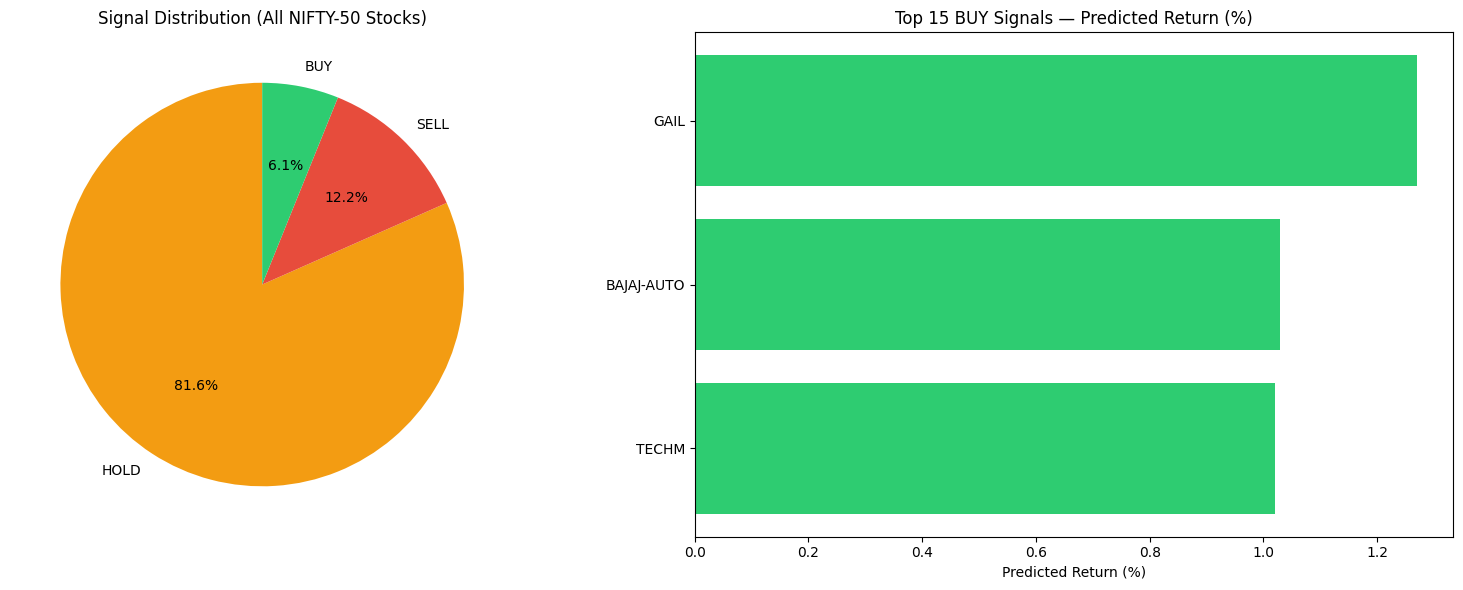

In [16]:
# ── CELL 13: Signals Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Signal distribution pie chart
signal_counts = signals_df['Signal'].value_counts()
colors = {'BUY': '#2ecc71', 'HOLD': '#f39c12', 'SELL': '#e74c3c'}
axes[0].pie(
    signal_counts.values,
    labels=signal_counts.index,
    autopct='%1.1f%%',
    colors=[colors[s] for s in signal_counts.index],
    startangle=90
)
axes[0].set_title('Signal Distribution (All NIFTY-50 Stocks)', fontsize=12)

# Top 15 BUY signals by predicted return
buy_df = signals_df[signals_df['Signal'] == 'BUY'].head(15)
axes[1].barh(buy_df['Symbol'], buy_df['Predicted_Return_Pct'], color='#2ecc71')
axes[1].set_title('Top 15 BUY Signals — Predicted Return (%)', fontsize=12)
axes[1].set_xlabel('Predicted Return (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
# ── CELL 14: Save Everything to Google Drive (for Notebook 3) ─────────────────
from google.colab import drive
drive.mount('/content/drive')

# Save model performance results
results_df.to_csv('/content/drive/MyDrive/nifty50_model_results.csv', index=False)

# Save BUY/HOLD/SELL signals
signals_df.to_csv('/content/drive/MyDrive/nifty50_signals.csv', index=False)

print("All files saved to Google Drive ✅")
print(f"  nifty50_model_results.csv  → {results_df.shape}")
print(f"  nifty50_signals.csv        → {signals_df.shape}")
print("\nReady for Notebook 3 (Portfolio Construction) 🚀")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive ✅
  nifty50_model_results.csv  → (49, 4)
  nifty50_signals.csv        → (49, 6)

Ready for Notebook 3 (Portfolio Construction) 🚀
